In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)

In [3]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
#val = pd.read_parquet('data/val.parquet')

In [5]:
one_hot_columns = ['Is_HTTP',
 'Is_HTTPS',
 'Is_FTP_Control',
 'Is_FTP_Data',
 'Is_SSH',
 'Is_Telnet',
 'Is_SMTP',
 'Is_DNS',
 'Is_POP3',
 'Is_IMAP',
 'Is_DHCP',
 'Is_SNMP',
 'Is_LDAP',
 'Is_LDAPS',
 'Is_SMB_CIFS',
 'Is_RDP',
 'Is_SIP',
 'Is_TFTP',
 'Is_MySQL',
 'Is_PostgreSQL',
 'Is_Oracle',
 'Is_HTTP_Alt_8080',
 'Is_HTTP_Alt_8081',
 'Is_HTTP_Alt_80',
 'Is_HTTPS_Alt_8443',
 'Is_Syslog',
 'Is_VNC',
 'Is_IRC',
 'Is_NTP',
 'Is_Kerberos',
 'Is_LDAP_Alt',
 'Is_LDAPS_Alt',
 'Is_RADIUS',
 'Is_PPTP',
 'Is_RTSP',
 'Is_X11',
 'Is_SNMP_Trap',
 'Is_BGP',
 'Is_IMAPS_Alt',
 'Is_POP3S_Alt',
 'Is_Telnet_SSL',
 'Is_NNTP',
 'Is_NNTPS',
 'Is_LDAP_TLS',
 'Is_AFS',
 'Is_NFS',
 'Is_SOCKS',
 'Is_RSYNC',
 'Is_CUPS',
 'Is_TFTP_Alt',
 'Is_Modbus',
 'Is_CoAP',
 'Is_MQTT',
 'Is_AMQP',
 'Is_Redis',
 'Is_Memcached',
 'Is_Elasticsearch',
 'Is_Zookeeper',
 'Is_Cassandra',
 'Is_Docker',
 'Is_Kubernetes',
 'Is_SMB_Direct',
 'Is_iSCSI',
 'Is_AFP',
 'Is_DHCPv6',
 'Is_RIPng',
 'Is_OSPF',
 'Is_PPPoE',
 'Is_L2TP',
 'Is_GRE',
 'Is_ESP',
 'Is_AH']

# Sum the columns to get the counts
counts = train[one_hot_columns].sum()

print(counts)

Is_HTTP               31404
Is_HTTPS             288341
Is_FTP_Control           11
Is_FTP_Data              51
Is_SSH                12221
Is_Telnet                68
Is_SMTP                1383
Is_DNS                27512
Is_POP3                  12
Is_IMAP                 242
Is_DHCP                  60
Is_SNMP                  66
Is_LDAP                 912
Is_LDAPS                  1
Is_SMB_CIFS             130
Is_RDP                   13
Is_SIP                    2
Is_TFTP                  33
Is_MySQL                  3
Is_PostgreSQL             0
Is_Oracle                 0
Is_HTTP_Alt_8080        761
Is_HTTP_Alt_8081          1
Is_HTTP_Alt_80         1244
Is_HTTPS_Alt_8443         1
Is_Syslog               219
Is_VNC                    0
Is_IRC                    3
Is_NTP                15640
Is_Kerberos              23
Is_LDAP_Alt               2
Is_LDAPS_Alt              0
Is_RADIUS                 4
Is_PPTP                   0
Is_RTSP                   0
Is_X11              

In [10]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def eval(votes, true_labels):
    # Generate the classification report
    report = classification_report(true_labels, votes)

    # Print the classification report
    print(report)
    # 1. Generate the confusion matrix
    cm = confusion_matrix(true_labels, votes)

    # 2. Visualize the confusion matrix (optional, but highly recommended)
    class_labels = np.unique(true_labels) # Get unique class labels

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Print the confusion matrix (textual representation)
    print(cm)

    # 1. Generate the classification report as a dictionary
    report = classification_report(true_labels, votes, output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1_score = [report[cls]['f1-score'] for cls in classes]

    # 3. Set up the plot
    x = np.arange(len(classes))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision, width, label='Recall')
    rects2 = ax.bar(x, recall, width, label='Precision')
    rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_xlabel('Classes')
    ax.set_title('Classification Report per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.bar_label(rects3, fmt='%.2f', padding=3)

    fig.tight_layout()
    plt.show()

In [19]:
x_cols = ['Min_PacketSpeed',
 'Std_DataSpeed',
 'Std_DetectCount',
 'Mean_DetectCount',
 'Avg source IP count',
 'Max_DetectCount',
 'Attack ID',
 'Max_PacketSpeed',
 'total_seconds',
 'AvgPacketLen_Std',
 'Mean_DataSpeed',
 'Mean_PacketSpeed',
 'Source IP count',
 'Cos_DayOfYear',
 'Sin_DayOfYear',
 'DayOfYear',
 'AvgPacketLen_Mean',
 'Min_DataSpeed',
 'PCA_4',
 'Start Hour']

In [3]:
x_cols = ['Attack ID',
 'Avg source IP count',
 'Detect count',
 'Victim IP',
 'Port number',
 'Packet speed',
 'Data speed',
 'Avg packet len',
 'Source IP count',
 'Packet speed_normalized',
 'Data speed_normalized',
 'Avg packet len_normalized',
 'total_seconds',
 'weekday_number',
 'time_of_day',
 'IsWeekend',
 'Start Hour',
 'Sin_Hour',
 'Cos_Hour',
 'DayOfYear',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'Mean_DataSpeed',
 'Std_DataSpeed',
 'Min_DataSpeed',
 'Max_DataSpeed',
 'Mean_PacketSpeed',
 'Min_PacketSpeed',
 'Max_PacketSpeed',
 'Mean_DetectCount',
 'Std_DetectCount',
 'Min_DetectCount',
 'Max_DetectCount',
 'VictimIP_Count',
 'PortNumber_Count',
 'AvgPacketLen_Mean',
 'AvgPacketLen_Std',
 'DataSpeed_PacketSpeed',
 'PortFrequency',
 'Std_DataSpeed_Replaced',
 'Std_DetectCount_Replaced',
 'AvgPacketLen_Std_Replaced',
 'packet_Total',
 'PacketSpeed_Per_Second',
 'DataSpeed_Per_TotalSeconds',
 'AvgPacketLen_Per_TotalSeconds',
 'PCA_1',
 'PCA_2',
 'PCA_3',
 'PCA_4',
 'PCA_5',
 'cluster',
 'cluster112',
 'dist_centroid_silhouette_0',
 'dist_centroid_silhouette_1',
 'dist_centroid_silhouette_2',
 'dist_centroid_silhouette_3',
 'dist_centroid_silhouette_4',
 'dist_centroid_silhouette_5',
 'dist_centroid_silhouette_6',
 'dist_centroid_silhouette_7',
 'dist_centroid_silhouette_8',
 'dist_centroid_silhouette_9',
 'dist_centroid_silhouette_10',
 'dist_centroid_silhouette_11',
 'dist_centroid_silhouette_12',
 'dist_centroid_silhouette_13',
 'dist_centroid_silhouette_14',
 'dist_centroid_silhouette_15',
 'dist_centroid_silhouette_16',
 'dist_centroid_silhouette_17',
 'dist_centroid_silhouette_18',
 'dist_centroid_silhouette_19',
 'dist_centroid_silhouette_20',
 'dist_centroid_silhouette_21',
 'dist_centroid_silhouette_22',
 'dist_centroid_silhouette_23',
 'dist_centroid_silhouette_24',
 'dist_centroid_silhouette_25',
 'dist_centroid_silhouette_26',
 'dist_centroid_silhouette_27',
 'dist_centroid_silhouette_28',
 'dist_centroid_silhouette_29',
 'dist_centroid_silhouette_30',
 'dist_centroid_silhouette_31',
 'dist_centroid_silhouette_32',
 'dist_centroid_silhouette_33',
 'dist_centroid_silhouette_34',
 'dist_centroid_silhouette_35',
 'dist_centroid_silhouette_36',
 'dist_centroid_silhouette_37',
 'dist_centroid_silhouette_38',
 'dist_centroid_silhouette_39',
 'dist_centroid_silhouette_40',
 'dist_centroid_silhouette_41',
 'dist_centroid_silhouette_42',
 'dist_centroid_silhouette_43',
 'dist_centroid_silhouette_44',
 'dist_centroid_silhouette_45',
 'dist_centroid_silhouette_46',
 'dist_centroid_silhouette_47',
 'dist_centroid_silhouette_48',
 'dist_centroid_silhouette_49',
 'dist_centroid_silhouette_50',
 'dist_centroid_silhouette_51',
 'dist_centroid_silhouette_52',
 'dist_centroid_silhouette_53',
 'dist_centroid_silhouette_54',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_56',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_59',
 'dist_centroid_silhouette_60',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_62',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_64',
 'dist_centroid_silhouette_65',
 'dist_centroid_silhouette_66',
 'dist_centroid_silhouette_67',
 'dist_centroid_silhouette_68',
 'dist_centroid_silhouette_69',
 'dist_centroid_silhouette_70',
 'dist_centroid_silhouette_71',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_73',
 'dist_centroid_silhouette_74',
 'dist_centroid_silhouette_75',
 'dist_centroid_silhouette_76',
 'dist_centroid_silhouette_77',
 'dist_centroid_silhouette_78',
 'dist_centroid_silhouette_79',
 'dist_centroid_silhouette_80',
 'dist_centroid_silhouette_81',
 'dist_centroid_silhouette_82',
 'dist_centroid_silhouette_83',
 'dist_centroid_silhouette_84',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_86',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_91',
 'dist_centroid_silhouette_92',
 'dist_centroid_silhouette_93',
 'dist_centroid_silhouette_94',
 'dist_centroid_silhouette_95',
 'dist_centroid_silhouette_96',
 'dist_centroid_silhouette_97',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_100',
 'dist_centroid_silhouette_101',
 'dist_centroid_silhouette_102',
 'dist_centroid_silhouette_103',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_105',
 'dist_centroid_silhouette_106',
 'dist_centroid_silhouette_107',
 'dist_centroid_silhouette_108',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_110',
 'dist_centroid_silhouette_111',
 'dist_centroid_0',
 'dist_centroid_1',
 'dist_centroid_2',
 'dist_centroid_3',
 'dist_centroid_4',
 'dist_centroid_5',
 'dist_centroid_6',
 'dist_centroid_7',
 'dist_centroid_8',
 'dist_centroid_9',
 'dist_centroid_10',
 'dist_centroid_11',
 'dist_centroid_12',
 'dist_centroid_13',
 'dist_centroid_14',
 'dist_centroid_15',
 'dist_centroid_16',
 'dist_centroid_17',
 'dist_centroid_18',
 'dist_centroid_19',
 'umap_1',
 'umap_2',
 'tsne_0',
 'tsne_1',
 'Is_HTTP',
 'Is_HTTPS',
 'Is_FTP_Control',
 'Is_FTP_Data',
 'Is_SSH',
 'Is_Telnet',
 'Is_SMTP',
 'Is_DNS',
 'Is_POP3',
 'Is_IMAP',
 'Is_DHCP',
 'Is_SNMP',
 'Is_LDAP',
 'Is_LDAPS',
 'Is_SMB_CIFS',
 'Is_RDP',
 'Is_SIP',
 'Is_TFTP',
 'Is_MySQL',
 'Is_PostgreSQL',
 'Is_Oracle',
 'Is_HTTP_Alt_8080',
 'Is_HTTP_Alt_8081',
 'Is_HTTP_Alt_80',
 'Is_HTTPS_Alt_8443',
 'Is_Syslog',
 'Is_VNC',
 'Is_IRC',
 'Is_NTP',
 'Is_Kerberos',
 'Is_LDAP_Alt',
 'Is_LDAPS_Alt',
 'Is_RADIUS',
 'Is_PPTP',
 'Is_RTSP',
 'Is_X11',
 'Is_SNMP_Trap',
 'Is_BGP',
 'Is_IMAPS_Alt',
 'Is_POP3S_Alt',
 'Is_Telnet_SSL',
 'Is_NNTP',
 'Is_NNTPS',
 'Is_LDAP_TLS',
 'Is_AFS',
 'Is_NFS',
 'Is_SOCKS',
 'Is_RSYNC',
 'Is_CUPS',
 'Is_TFTP_Alt',
 'Is_Modbus',
 'Is_CoAP',
 'Is_MQTT',
 'Is_AMQP',
 'Is_Redis',
 'Is_Memcached',
 'Is_Elasticsearch',
 'Is_Zookeeper',
 'Is_Cassandra',
 'Is_Docker',
 'Is_Kubernetes',
 'Is_SMB_Direct',
 'Is_iSCSI',
 'Is_AFP',
 'Is_DHCPv6',
 'Is_RIPng',
 'Is_OSPF',
 'Is_PPPoE',
 'Is_L2TP',
 'Is_GRE',
 'Is_ESP',
 'Is_AH']

In [11]:
x_cols = ['Min_PacketSpeed',
 'Std_DataSpeed',
 'Std_DetectCount',
 'Mean_DetectCount',
 'Avg source IP count',
 'Max_DetectCount',
 'Attack ID',
 'Max_PacketSpeed',
 'total_seconds',
 'AvgPacketLen_Std',
 'Mean_DataSpeed',
 'Mean_PacketSpeed',
 'Source IP count',
 'Cos_DayOfYear',
 'Sin_DayOfYear',
 'DayOfYear',
 'AvgPacketLen_Mean',
 'Min_DataSpeed',
 'PCA_4',
 'Start Hour']

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


def objective(trial):
    # Define the hyperparameters to optimize and their search spaces
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

    # Create the Random Forest Classifier with the suggested hyperparameters
    rfc = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42, 
        verbose=0,
        class_weight='balanced',
        )

    # Train the model
    rfc.fit(train[x_cols], train['Type'])

    # Make predictions on the test set
    y_pred = rfc.predict(test[x_cols])

    # Calculate the evaluation metric (accuracy in this case)
    accuracy = f1_score(test['Type'], y_pred, average='macro')
    return accuracy

if __name__ == "__main__":
    # Create a study object and specify the optimization direction
    study = optuna.create_study(direction='maximize')

    # Run the optimization process
    study.optimize(objective, n_trials=50, show_progress_bar=True)  # Number of trials to run

    # Print the best hyperparameters found
    print("Best hyperparameters:", study.best_params)

    # Get the best score achieved
    print("Best accuracy:", study.best_value)

[I 2026-05-26 00:10:29,445] A new study created in memory with name: no-name-601219f2-a38e-4133-8b12-8fbd78c079cd


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-26 00:32:17,074] Trial 0 finished with value: 0.6201784777165225 and parameters: {'n_estimators': 299, 'max_depth': 49, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.6201784777165225.
[I 2026-05-26 00:59:29,779] Trial 1 finished with value: 0.6284581203901081 and parameters: {'n_estimators': 364, 'max_depth': 36, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.6284581203901081.
[I 2026-05-26 01:04:17,166] Trial 2 finished with value: 0.6974090937736458 and parameters: {'n_estimators': 65, 'max_depth': 45, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.6974090937736458.
[I 2026-05-26 01:32:34,420] Trial 3 finished with value: 0.6261542825125989 and parameters: {'n_estimators': 374, 'max_depth': 38, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.6974090937736458.
[I 2026-05-26 01:59:06,005] Trial 4 finished with value: 0.631704464584156 and parameters: {'

KeyboardInterrupt: 

In [ ]:
print("Best hyperparameters:", study.best_params)

Best hyperparameters: {'n_estimators': 65, 'max_depth': 45, 'min_samples_split': 8, 'min_samples_leaf': 4}


Accuracy of the best model on the test set: 0.6397


              precision    recall  f1-score   support

           0       0.57      0.89      0.69    305167
           1       0.94      0.78      0.85    919196
           2       0.61      0.28      0.38     22903

    accuracy                           0.79   1247266
   macro avg       0.70      0.65      0.64   1247266
weighted avg       0.84      0.79      0.80   1247266



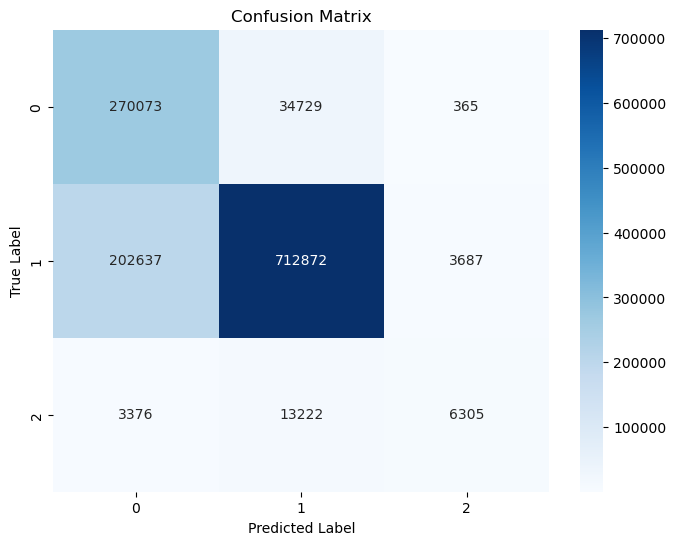

[[270073  34729    365]
 [202637 712872   3687]
 [  3376  13222   6305]]


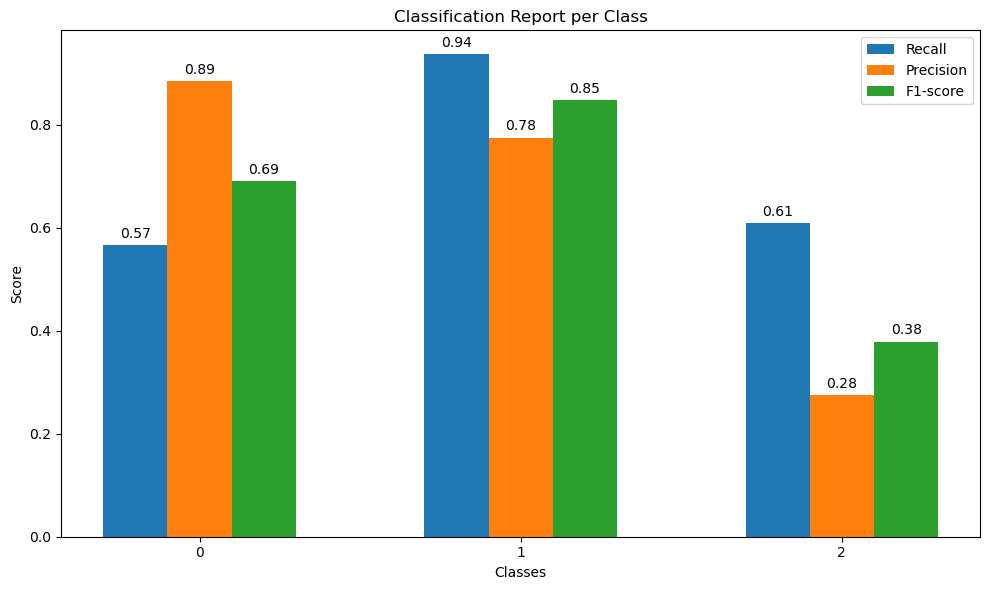

In [ ]:
best_rfc = RandomForestClassifier(**study.best_params, random_state=42)

# Train the best model on the full training data
best_rfc.fit(train[x_cols], train['Type'])

# Evaluate the best model on the test setí
y_pred_best = best_rfc.predict(test[x_cols])
best_accuracy = f1_score(test['Type'], y_pred_best, average='macro')
print(f"Accuracy of the best model on the test set: {best_accuracy:.4f}")

# You can also visualize the optimization history and parameter importance
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()

eval(y_pred_best, test['Type'])

In [3]:
x_cols = ['total_seconds',
 'AvgPacketLen_Mean',
 'Avg source IP count',
 'Max_DetectCount',
 'Std_DataSpeed',
 'AvgPacketLen_Std',
 'Min_PacketSpeed',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'Mean_DataSpeed',
 'Max_DataSpeed',
 'Mean_PacketSpeed',
 'Attack ID',
 'Max_PacketSpeed',
 'Victim IP',
 'AvgPacketLen_Per_TotalSeconds',
 'Mean_DetectCount',
 'Start Hour',
 'Min_DataSpeed',
 'DayOfYear',
 'VictimIP_Count',
 'Std_DetectCount',
 'PCA_3',
 'PCA_4',
 'PacketSpeed_Per_Second',
 'Source IP count',
 'PCA_2',
 'umap_2',
 'Is_SSH',
 'dist_centroid_silhouette_54']

In [5]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score
#30
def objective(trial):
    # Define the hyperparameters to optimize and their search spaces for LightGBM
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    num_leaves = trial.suggest_int('num_leaves', 31, 100)
    max_depth = trial.suggest_int('max_depth', -1, 10)  # -1 means no limit
    min_child_samples = trial.suggest_int('min_child_samples', 20, 50)
    subsample = trial.suggest_float('subsample', 0.7, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.7, 1.0)

    # Create the LightGBM Classifier with the suggested hyperparameters
    lgbm = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        verbose=-1,
        class_weight='balanced',
    )

    # Train the model
    lgbm.fit(train[x_cols], train['Type'])

    # Make predictions on the test set
    y_pred = lgbm.predict(test[x_cols])

    # Calculate the evaluation metric (accuracy in this case)
    accuracy = f1_score(test['Type'], y_pred, average='macro')
    return accuracy

if __name__ == "__main__":
    # Create a study object and specify the optimization direction
    study = optuna.create_study(direction='maximize')

    # Run the optimization process
    study.optimize(objective, n_trials=50, show_progress_bar=True)  # Number of trials to run

[I 2026-05-26 12:42:57,610] A new study created in memory with name: no-name-4e8dc577-4889-4b9f-8358-b33ed6f99ceb


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-26 12:43:24,575] Trial 0 finished with value: 0.5685079073966101 and parameters: {'n_estimators': 217, 'learning_rate': 0.07209541660012173, 'num_leaves': 37, 'max_depth': 2, 'min_child_samples': 39, 'subsample': 0.9084844683796509, 'colsample_bytree': 0.8200165040519107}. Best is trial 0 with value: 0.5685079073966101.
[I 2026-05-26 12:44:17,997] Trial 1 finished with value: 0.44418389295038363 and parameters: {'n_estimators': 258, 'learning_rate': 0.19806892451614225, 'num_leaves': 69, 'max_depth': -1, 'min_child_samples': 36, 'subsample': 0.7264787323385943, 'colsample_bytree': 0.8792087669697615}. Best is trial 0 with value: 0.5685079073966101.
[I 2026-05-26 12:44:50,546] Trial 2 finished with value: 0.5432006943701776 and parameters: {'n_estimators': 128, 'learning_rate': 0.01158381216924002, 'num_leaves': 89, 'max_depth': 10, 'min_child_samples': 47, 'subsample': 0.8832893836796953, 'colsample_bytree': 0.876451004762947}. Best is trial 0 with value: 0.5685079073966101.

KeyboardInterrupt: 

In [6]:
print("Best hyperparameters:", study.best_params)

# Get the best score achieved
print("Best accuracy:", study.best_value)

# Create a model with the best hyperparameters
best_lgbm = lgb.LGBMClassifier(**study.best_params, random_state=42)

# Train the best model on the full training data
best_lgbm.fit(train[x_cols], train['Type'])

# Evaluate the best model on the test set
y_pred_best = best_lgbm.predict(test[x_cols])
best_accuracy = f1_score(test['Type'], y_pred_best, average='macro')
print(f"Accuracy of the best LightGBM model on the test set: {best_accuracy:.4f}")

# You can also visualize the optimization history and parameter importance
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()

Best hyperparameters: {'n_estimators': 383, 'learning_rate': 0.11854306783765164, 'num_leaves': 33, 'max_depth': 2, 'min_child_samples': 29, 'subsample': 0.8290420637175341, 'colsample_bytree': 0.7072656603944018}
Best accuracy: 0.6027386999248364
Accuracy of the best LightGBM model on the test set: 0.5951


              precision    recall  f1-score   support

           0       0.60      0.69      0.64    305167
           1       0.89      0.86      0.87    919196
           2       0.67      0.17      0.27     22903

    accuracy                           0.81   1247266
   macro avg       0.72      0.57      0.60   1247266
weighted avg       0.81      0.81      0.81   1247266



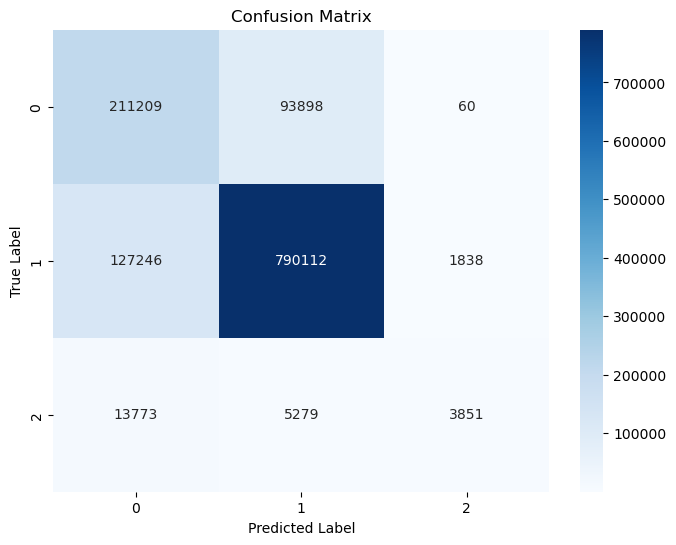

[[211209  93898     60]
 [127246 790112   1838]
 [ 13773   5279   3851]]


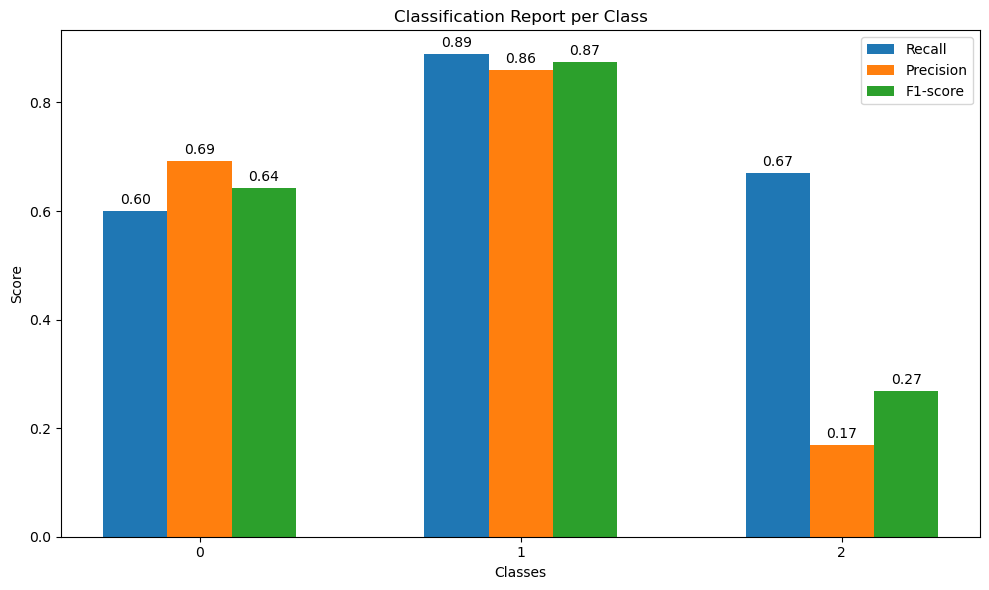

In [7]:
eval(y_pred_best, test['Type'])

In [7]:
"""Best hyperparameters: {'n_estimators': 341, 'learning_rate': 0.05719243532859288, 'num_leaves': 47, 'max_depth': 5, 
'min_child_samples': 42, 'subsample': 0.8896113748808988, 'colsample_bytree': 0.9577482057904019}
Best f1: 0.6048903438655178
"""

"Best hyperparameters: {'n_estimators': 341, 'learning_rate': 0.05719243532859288, 'num_leaves': 47, 'max_depth': 5, \n'min_child_samples': 42, 'subsample': 0.8896113748808988, 'colsample_bytree': 0.9577482057904019}\nBest f1: 0.6048903438655178\n"

In [9]:
x_cols = ['dist_centroid_silhouette_72',
 'Avg source IP count',
 'PCA_4',
 'dist_centroid_silhouette_61',
 'PCA_3',
 'Std_DetectCount',
 'Is_SSH',
 'dist_centroid_silhouette_54',
 'Std_DataSpeed',
 'umap_2',
 'Min_PacketSpeed',
 'Data speed',
 'Mean_DetectCount',
 'Victim IP',
 'Min_DataSpeed',
 'AvgPacketLen_Mean',
 'Attack ID',
 'PacketSpeed_Per_Second',
 'PCA_2',
 'Mean_PacketSpeed']

[I 2026-05-25 23:55:11,790] A new study created in memory with name: no-name-19e54543-5265-4b1a-8cff-78870af9da03


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\xgboost\training.py:200: UserWarning:

[23:55:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.


c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\xgboost\core.py:751: UserWarning:

[23:55:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.




[I 2026-05-25 23:55:18,001] Trial 0 finished with value: 0.6053944962839377 and parameters: {'booster': 'gbtree', 'alpha': 0.9603499108303545, 'subsample': 0.6978742787789822, 'colsample_bytree': 0.48314203657588417, 'max_depth': 5, 'eta': 0.13634285572353377, 'gamma': 0.7143747273358818, 'grow_policy': 'lossguide', 'min_child_weight': 3}. Best is trial 0 with value: 0.6053944962839377.


c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\xgboost\training.py:200: UserWarning:

[23:55:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "colsample_bytree", "gamma", "grow_policy", "max_depth", "min_child_weight", "subsample" } are not used.




...

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\xgboost\training.py:200: UserWarning:

[00:07:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.




[I 2026-05-26 00:07:24,642] Trial 48 finished with value: 0.5863977978517203 and parameters: {'booster': 'dart', 'alpha': 0.7185213951554702, 'subsample': 0.3325178126220847, 'colsample_bytree': 0.8059853765136795, 'max_depth': 5, 'eta': 0.24191291547646276, 'gamma': 0.5622043833559274, 'grow_policy': 'depthwise', 'min_child_weight': 8}. Best is trial 42 with value: 0.6220867786614847.


c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\xgboost\training.py:200: UserWarning:

[00:07:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.




[I 2026-05-26 00:07:29,357] Trial 49 finished with value: 0.6235449095531964 and parameters: {'booster': 'gbtree', 'alpha': 0.43956717471385465, 'subsample': 0.5248001386035008, 'colsample_bytree': 0.8647362305652437, 'max_depth': 4, 'eta': 0.17688927631326914, 'gamma': 0.7809600844789752, 'grow_policy': 'lossguide', 'min_child_weight': 7}. Best is trial 49 with value: 0.6235449095531964.
Best hyperparameters: {'booster': 'gbtree', 'alpha': 0.43956717471385465, 'subsample': 0.5248001386035008, 'colsample_bytree': 0.8647362305652437, 'max_depth': 4, 'eta': 0.17688927631326914, 'gamma': 0.7809600844789752, 'grow_policy': 'lossguide', 'min_child_weight': 7}
Best accuracy: 0.6235449095531964
Accuracy of the best XGBoost model on the test set: 0.5982


              precision    recall  f1-score   support

           0       0.61      0.60      0.60    305167
           1       0.86      0.88      0.87    919196
           2       0.96      0.19      0.32     22903

    accuracy                           0.80   1247266
   macro avg       0.81      0.56      0.60   1247266
weighted avg       0.80      0.80      0.79   1247266



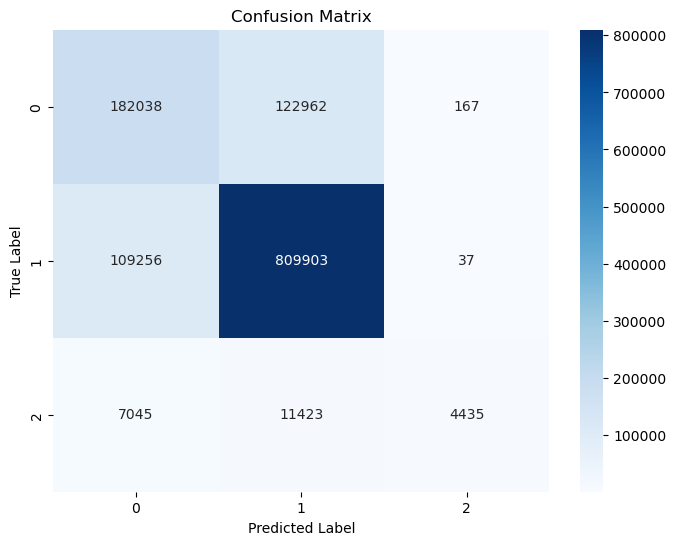

[[182038 122962    167]
 [109256 809903     37]
 [  7045  11423   4435]]


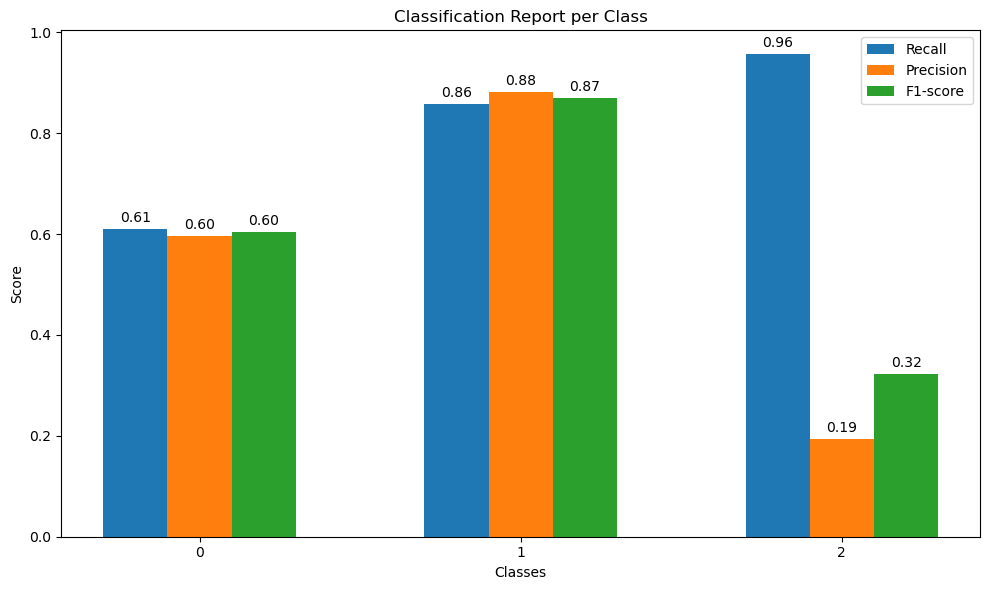

In [ ]:
import optuna
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

def objective(trial):
    # Create the XGBM Classifier with the suggested hyperparameters
    xgb = XGBClassifier(
        device='cuda',
        objective='multi:softmax',
        num_class=3,
        booster=trial.suggest_categorical('booster', ['gbtree', 'gblinear', 'dart']),
        alpha=trial.suggest_float('alpha', 1e-8, 1.0),
        subsample=trial.suggest_float('subsample', 0.2, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.2, 1.0),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        eta=trial.suggest_float('eta', 0.005, 0.3),
        gamma=trial.suggest_float('gamma', 1e-8, 1.0),
        grow_policy=trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42,
    )

    # Train the model
    xgb.fit(train[x_cols], train['Type'])

    # Make predictions on the test set
    y_pred = xgb.predict(test[x_cols])

    # Calculate the evaluation metric (accuracy in this case)
    accuracy = f1_score(test['Type'], y_pred, average='macro')
    return accuracy

if __name__ == "__main__":
    # Create a study object and specify the optimization direction
    study = optuna.create_study(direction='maximize')

    # Run the optimization process
    study.optimize(objective, n_trials=50, show_progress_bar=True)  # Number of trials to run

    # Print the best hyperparameters found
    print("Best hyperparameters:", study.best_params)

    # Get the best score achieved
    print("Best accuracy:", study.best_value)

    # Create a model with the best hyperparameters
    best_xgb = xgb.XGBClassifier(**study.best_params, random_state=42)

    # Train the best model on the full training data
    best_xgb.fit(train[x_cols], train['Type'])

    # Evaluate the best model on the test set
    y_pred_best = best_xgb.predict(test[x_cols])
    best_accuracy = f1_score(test['Type'], y_pred_best, average='macro')
    print(f"Accuracy of the best XGBoost model on the test set: {best_accuracy:.4f}")

    # You can also visualize the optimization history and parameter importance
    optuna.visualization.plot_optimization_history(study).show()
    optuna.visualization.plot_param_importances(study).show()

    eval(y_pred_best, test['Type'])

In [ ]:
"""{'booster': 'gbtree', 'alpha': 0.8929914624140356, 'subsample': 0.5245590585473099, 'colsample_bytree': 0.41745486572446977, 'max_depth': 10, 
'eta': 0.03343544751435021, 'gamma': 0.36103800824329335, 'grow_policy': 'lossguide', 'min_child_weight': 2}. Best is trial 26 with value: 0.5978143690983727."""

"{'booster': 'gbtree', 'alpha': 0.8929914624140356, 'subsample': 0.5245590585473099, 'colsample_bytree': 0.41745486572446977, 'max_depth': 10, \n'eta': 0.03343544751435021, 'gamma': 0.36103800824329335, 'grow_policy': 'lossguide', 'min_child_weight': 2}. Best is trial 26 with value: 0.5978143690983727."

: 

In [ ]:
# Optuna hyperparameter optimization for KNN
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 1, 5),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 1000),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }

    knn = KNeighborsClassifier(**params, n_jobs=-1)
    pipe = Pipeline([("scaler", StandardScaler()), ("knn", knn)])

    pipe.fit(train[x_cols], train["Type"])
    y_pred = pipe.predict(val[x_cols])
    return f1_score(val["Type"], y_pred, average="macro")

if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=20, show_progress_bar=True)

    print("Best hyperparameters:", study.best_params)
    print("Best f1 on validation:", study.best_value)

    # Train best model on train and evaluate on test
    best_knn = KNeighborsClassifier(**study.best_params, n_jobs=-1)
    best_pipe = Pipeline([("scaler", StandardScaler()), ("knn", best_knn)])
    best_pipe.fit(train[x_cols], train["Type"])
    y_test = best_pipe.predict(test[x_cols])
    test_f1 = f1_score(test["Type"], y_test, average="macro")
    print(f"Test f1 of best KNN: {test_f1:.4f}")

    # Optional visualization
    try:
        optuna.visualization.plot_optimization_history(study).show()
        optuna.visualization.plot_param_importances(study).show()
    except Exception:
        pass

[I 2025-10-26 18:24:29,104] A new study created in memory with name: no-name-039de3da-6735-41ad-a888-ba4e404712a9


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-10-26 23:50:02,050] Trial 0 finished with value: 0.5197061499624208 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'algorithm': 'kd_tree', 'leaf_size': 39, 'p': 2, 'metric': 'manhattan'}. Best is trial 0 with value: 0.5197061499624208.
[I 2025-10-27 13:30:56,393] Trial 1 finished with value: 0.5435936302925328 and parameters: {'n_neighbors': 36, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 31, 'p': 1, 'metric': 'manhattan'}. Best is trial 1 with value: 0.5435936302925328.
[I 2025-10-28 08:23:59,114] Trial 2 finished with value: 0.5505135477500015 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 12, 'p': 1, 'metric': 'chebyshev'}. Best is trial 2 with value: 0.5505135477500015.
[I 2025-10-28 23:45:32,914] Trial 3 finished with value: 0.5418060016032084 and parameters: {'n_neighbors': 19, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 19, 'p': 1, 'metric': 'manhattan'}. Best is trial 2 with value: 0.

In [ ]:
"""{'n_neighbors': 1, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 48, 'p': 1, 'metric': 'chebyshev'}. Best is trial 10 with value: 0.5640370214460121"""

# Stacking Knn opt


In [11]:
x_cols = ['Min_PacketSpeed',
 'Mean_DetectCount',
 'Avg source IP count',
 'Max_DetectCount',
 'Std_DataSpeed',
 'Std_DetectCount',
 'Attack ID',
 'total_seconds',
 'AvgPacketLen_Mean',
 'Mean_DataSpeed',
 'Max_PacketSpeed',
 'AvgPacketLen_Std',
 'Source IP count',
 'Mean_PacketSpeed',
 'DayOfYear',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'PCA_4',
 'PCA_3',
 'AvgPacketLen_Per_TotalSeconds',
 'Min_DataSpeed',
 'Start Hour',
 'PCA_5',
 'Max_DataSpeed',
 'VictimIP_Count',
 'PCA_2',
 'Cos_Hour',
 'Sin_Hour',
 'Victim IP',
 'weekday_number',
 'dist_centroid_silhouette_54',
 'time_of_day',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_39',
 'Port number',
 'dist_centroid_17',
 'dist_centroid_silhouette_72',
 'Detect count',
 'dist_centroid_silhouette_62']

In [20]:
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

rf_clf = RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced')
lgbm_clf = lgb.LGBMClassifier(verbose=-1, n_estimators=207, learning_rate=0.10377336349859621, num_leaves=43, max_depth=4, 
                          min_child_samples=32, subsample=0.7162551022950866, colsample_bytree=0.8389154148971049, random_state=42, is_unbalance=True)
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('dart'),
        alpha=0.1376594223943208,
        subsample=0.48709556518103037,
        colsample_bytree=0.4618965478306953,
        max_depth=8,
        eta=0.16964607140138516,
        gamma=0.015840312300226367,
        grow_policy='depthwise',
        min_child_weight=3,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42
        )
train["rf_pred"] = rf_clf.fit(train[x_cols], train['Type']).predict_proba(train[x_cols])[:, 1]
train["lgbm_pred"] = lgbm_clf.fit(train[x_cols], train['Type']).predict_proba(train[x_cols])[:, 1]
train["xgb_pred"] = xgb_clf.fit(train[x_cols], train['Type']).predict_proba(train[x_cols])[:, 1]

test["rf_pred"] = rf_clf.predict_proba(test[x_cols])[:, 1]
test["lgbm_pred"] = lgbm_clf.predict_proba(test[x_cols])[:, 1]
test["xgb_pred"] = xgb_clf.predict_proba(test[x_cols])[:, 1]



In [21]:
x_cols_extended = ["rf_pred", "lgbm_pred", "xgb_pred"]

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score
import optuna

def objective(trial):
    # 1. Define the KNN Search Space
    params = {'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 100),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'class_weight': 'balanced', # Keep this fixed for imbalance!
        'random_state': 42}

    knn = DecisionTreeClassifier(**params)

    knn.fit(train[x_cols_extended], train["Type"])
    y_pred = knn.predict(test[x_cols_extended])
    return f1_score(test["Type"], y_pred, average="macro")

if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print("Best hyperparameters:", study.best_params)
    print("Best f1 on validation:", study.best_value)

    # Train best model on train and evaluate on test
    best_knn = DecisionTreeClassifier(**study.best_params)
    best_knn.fit(train[x_cols_extended], train["Type"])
    y_test = best_knn.predict(test[x_cols_extended])
    test_f1 = f1_score(test["Type"], y_test, average="macro")
    print(f"Test f1 of best KNN: {test_f1:.4f}")

    # Optional visualization
    try:
        optuna.visualization.plot_optimization_history(study).show()
        optuna.visualization.plot_param_importances(study).show()
    except Exception:
        pass

[I 2026-05-27 01:25:37,520] A new study created in memory with name: no-name-989f25f5-778e-4567-ad40-19880cde61ec


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 01:25:39,998] Trial 0 finished with value: 0.32599272970918736 and parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 28, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.32599272970918736.
[I 2026-05-27 01:25:42,913] Trial 1 finished with value: 0.2780026339066598 and parameters: {'criterion': 'log_loss', 'max_depth': 5, 'min_samples_split': 61, 'min_samples_leaf': 26}. Best is trial 0 with value: 0.32599272970918736.
[I 2026-05-27 01:25:45,225] Trial 2 finished with value: 0.24245600274696033 and parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 62, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.32599272970918736.
[I 2026-05-27 01:25:46,844] Trial 3 finished with value: 0.3217637750023397 and parameters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 46, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.32599272970918736.
[I 2026-05-27 01:25:51,900] Trial 4 finished with value: 0.35692541891454826 

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


def eval(votes, true_labels):
    # Generate the classification report
    report = classification_report(true_labels, votes)

    # Print the classification report
    print(report)
    # 1. Generate the confusion matrix
    cm = confusion_matrix(true_labels, votes)

    # 2. Visualize the confusion matrix (optional, but highly recommended)
    class_labels = np.unique(true_labels) # Get unique class labels

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Print the confusion matrix (textual representation)
    print(cm)

    # 1. Generate the classification report as a dictionary
    report = classification_report(true_labels, votes, output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1_score = [report[cls]['f1-score'] for cls in classes]

    # 3. Set up the plot
    x = np.arange(len(classes))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision, width, label='Recall')
    rects2 = ax.bar(x, recall, width, label='Precision')
    rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_xlabel('Classes')
    ax.set_title('Classification Report per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.bar_label(rects3, fmt='%.2f', padding=3)

    fig.tight_layout()
    plt.show()

              precision    recall  f1-score   support

           0       0.36      0.42      0.39    305167
           1       0.79      0.73      0.76    919196
           2       0.01      0.02      0.01     22903

    accuracy                           0.64   1247266
   macro avg       0.39      0.39      0.39   1247266
weighted avg       0.67      0.64      0.65   1247266



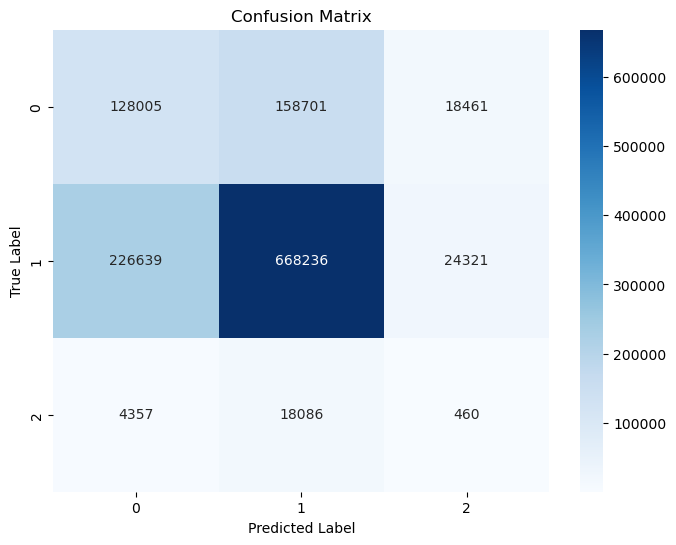

[[128005 158701  18461]
 [226639 668236  24321]
 [  4357  18086    460]]


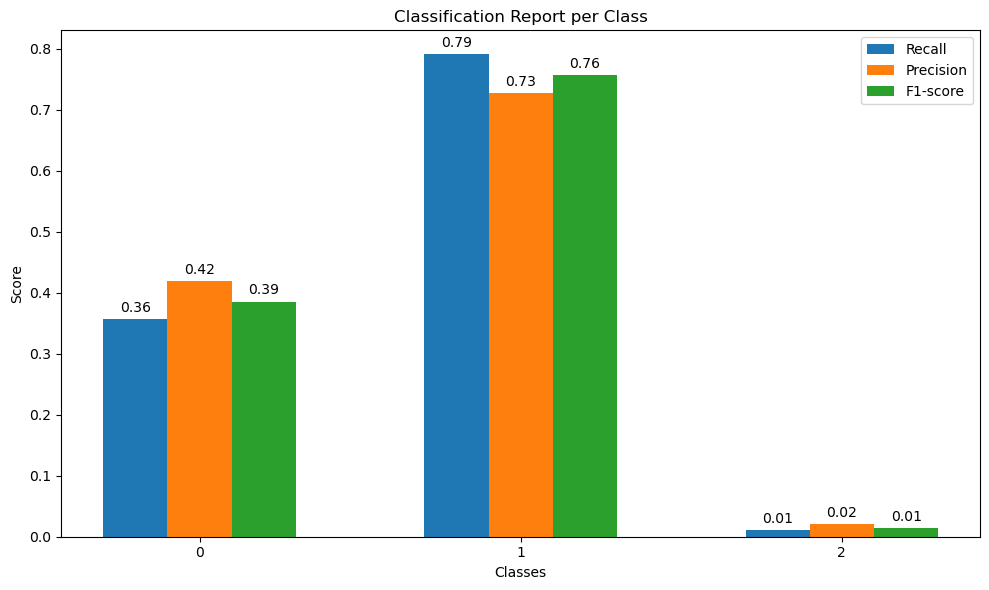

In [24]:
eval(y_test, test['Type'])

In [25]:
x_cols_extended = x_cols_extended + x_cols

[I 2026-05-27 01:28:44,439] A new study created in memory with name: no-name-d90fc1cb-c383-49e7-bff0-85ff06066d2b


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 01:37:02,674] Trial 0 finished with value: 0.489574377592449 and parameters: {'n_neighbors': 25, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.489574377592449.
[I 2026-05-27 01:40:57,250] Trial 1 finished with value: 0.4694633778495512 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.489574377592449.
[I 2026-05-27 01:46:14,119] Trial 2 finished with value: 0.47315155192797215 and parameters: {'n_neighbors': 26, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.489574377592449.
[I 2026-05-27 01:57:04,672] Trial 3 finished with value: 0.4899150670919354 and parameters: {'n_neighbors': 27, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 3 with value: 0.4899150670919354.
[I 2026-05-27 02:02:10,972] Trial 4 finished with value: 0.454071933756737 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 3 with 

              precision    recall  f1-score   support

           0       0.58      0.65      0.61    305167
           1       0.86      0.84      0.85    919196
           2       0.05      0.00      0.01     22903

    accuracy                           0.78   1247266
   macro avg       0.49      0.50      0.49   1247266
weighted avg       0.78      0.78      0.78   1247266



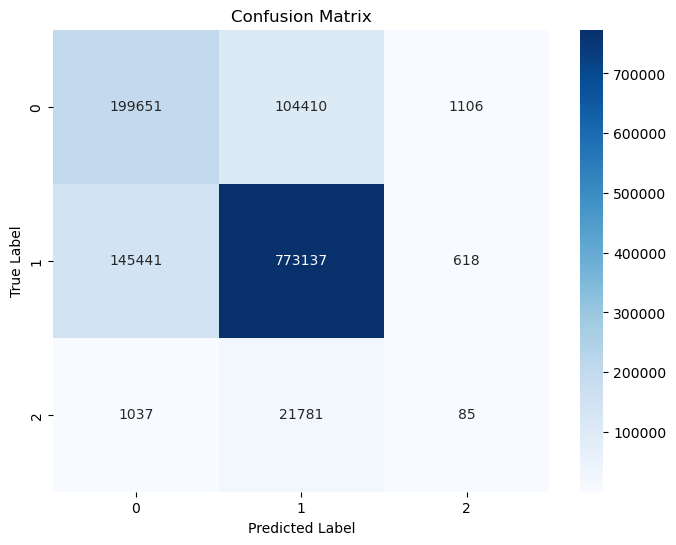

[[199651 104410   1106]
 [145441 773137    618]
 [  1037  21781     85]]


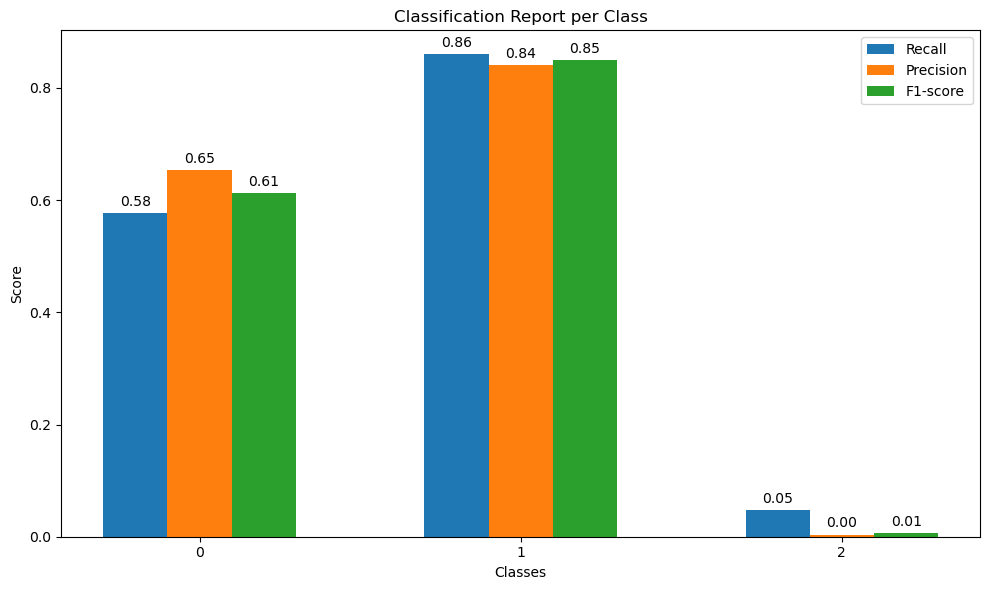

In [26]:
# Optuna hyperparameter optimization for KNN
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

def objective(trial):
    params = {
        # Test odd numbers between 3 and 31
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 31),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
        # algorithm='auto' can be slow; 'ball_tree' is usually fastest for tabular data
        'algorithm': 'ball_tree', 
        'n_jobs': -1 # Use all CPU cores
    }

    knn = KNeighborsClassifier(**params)
    #knn = GaussianNB(**params, random_state=42)

    knn.fit(train[x_cols_extended], train["Type"])
    y_pred = knn.predict(test[x_cols_extended])
    return f1_score(test["Type"], y_pred, average="macro")

if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print("Best hyperparameters:", study.best_params)
    print("Best f1 on validation:", study.best_value)

    # Train best model on train and evaluate on test
    best_knn = KNeighborsClassifier(**study.best_params)
    best_knn.fit(train[x_cols_extended], train["Type"])
    y_test = best_knn.predict(test[x_cols_extended])
    test_f1 = f1_score(test["Type"], y_test, average="macro")
    print(f"Test f1 of best KNN: {test_f1:.4f}")

    # Optional visualization
    try:
        optuna.visualization.plot_optimization_history(study).show()
        optuna.visualization.plot_param_importances(study).show()
    except Exception:
        pass

    eval(y_test, test['Type'])